<a href="https://colab.research.google.com/github/ConciseCoding/Inferno-Realtime-Fire-detection-using-CNNs/blob/master/PTQ_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Package Installation

In [ ]:
!pip install torchvision --quiet

import os
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from types import SimpleNamespace
from PIL import Image
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 29.3 MB/s eta 0:00:00


# Warmup Training Learning Rate Scheduler

In [ ]:
from torch.optim.lr_scheduler import _LRScheduler

class WarmUpLR(_LRScheduler):
    """warmup_training learning rate scheduler
    Args:
        optimizer: optimzier(e.g. SGD)
        total_iters: totoal_iters of warmup phase
    """
    def __init__(self, optimizer, total_iters, last_epoch=-1):

        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        """we will use the first m batches, and set the learning
        rate to base_lr * m / total_iters
        """
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

# Define PyTorch Model

In [ ]:
import torch
import math
import torch.nn.init as init
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_class=10, act_funct=nn.ReLU):
        super().__init__()
        self.Conv0 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.Conv1 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.Linear0 = nn.Linear(in_features=8 * 8 * 16, out_features=1024)
        self.Linear1 = nn.Linear(in_features=1024, out_features=num_class)
        self.MaxPool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Act     = act_funct()

        # Initialize weights
        self._init_weights()

    def forward(self, input):
        # Layer0
        output_layer0 = self.MaxPool(self.Act(self.Conv0(input)))
        # Layer1
        output_layer1 = self.MaxPool(self.Act(self.Conv1(output_layer0)))
        # Layer2
        output_flatten = torch.flatten(output_layer1, start_dim=1)
        output_layer2 = self.Linear0(output_flatten)
        # Layer3
        output_layer3 = self.Linear1(output_layer2)
        return output_layer3

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.kaiming_uniform_(m.weight, a=math.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / math.sqrt(fan_in)
                    init.uniform_(m.bias, -bound, bound)

# Define Arguement

In [ ]:
args = SimpleNamespace(
    num_class=10,
    resume=False,
    start_epoch=1,
    max_epochs=100,
    batch_size=128,
    num_workers=2,
    output_dir="Output"
)

# Data Loader

In [ ]:
def data_loader(args):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers)

    return train_loader, test_loader

# Training Function

In [ ]:
def train(args, epoch, model, train_loader, loss_func, optimizer, warmup_scheduler, device):
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_func(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch <= 1:
            warmup_scheduler.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy, running_loss

# Test Function for Testing While Training Process

In [ ]:
def test(args, model, val_loader, device):
    model.eval()
    correct_1 = 0.0
    correct_5 = 0.0
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = outputs.topk(5, 1, largest=True, sorted=True)
            labels = labels.view(labels.size(0), -1).expand_as(pred)
            correct = pred.eq(labels).float()
            correct_5 += correct[:, :5].sum()
            correct_1 += correct[:, :1].sum()
    top1_acc = (correct_1 / len(val_loader.dataset)) * 100
    top5_acc = (correct_5 / len(val_loader.dataset)) * 100
    return top1_acc, top5_acc

# Validation Function

In [ ]:
def validate(args, model, val_loader, device):
    model.eval()
    correct_1 = 0.0
    correct_5 = 0.0
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = outputs.topk(5, 1, largest=True, sorted=True)
            labels = labels.view(labels.size(0), -1).expand_as(pred)
            correct = pred.eq(labels).float()
            correct_5 += correct[:, :5].sum()
            correct_1 += correct[:, :1].sum()
    top1_acc = (correct_1 / len(val_loader.dataset)) * 100
    top5_acc = (correct_5 / len(val_loader.dataset)) * 100
    return top1_acc, top5_acc

# Training Process

In [ ]:
def training(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CNNModel(num_class=args.num_class).to(device)
    train_loader, val_loader = data_loader(args)

    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    train_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    iter_per_epoch = len(train_loader)
    warmup_scheduler = WarmUpLR(optimizer, iter_per_epoch)

    best_acc = 0.0
    for epoch in range(args.start_epoch, args.max_epochs + 1):
        print(f"\nEpoch: {epoch}")
        if epoch > 1:
            train_scheduler.step(epoch)

        train_acc, train_loss = train(args, epoch, model, train_loader, loss_func, optimizer, warmup_scheduler, device)
        print(f"Train Loss: {train_loss / len(train_loader):.4f}, Acc: {train_acc:.2f}%")

        val_top1acc, val_top5acc = test(args, model, val_loader, device)
        print(f"Top-1 Acc: {val_top1acc:.2f}%, Top-5 Acc: {val_top5acc:.2f}%")

        os.makedirs(args.output_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{args.output_dir}/model_regular.pt")

        if val_top1acc > best_acc:
            print("Saving best model...")
            torch.save(model.state_dict(), f"{args.output_dir}/model_best.pt")
            best_acc = val_top1acc

    print("Validating best model...")
    model.load_state_dict(torch.load(f"{args.output_dir}/model_best.pt"))
    val_top1acc, val_top5acc = validate(args, model, val_loader, device)
    print(f"Best Top-1 Accuracy: {val_top1acc:.2f}%")
    print(f"Best Top-5 Accuracy: {val_top5acc:.2f}%")

training(args)

100%|██████████| 170M/170M [00:08<00:00, 19.9MB/s]



Epoch: 1
Train Loss: 1.6589, Acc: 40.60%
Top-1 Acc: 49.28%, Top-5 Acc: 92.90%
Saving best model...

Epoch: 2


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.4277, Acc: 49.78%
Top-1 Acc: 51.11%, Top-5 Acc: 93.04%
Saving best model...

Epoch: 3
Train Loss: 1.3335, Acc: 53.16%
Top-1 Acc: 52.38%, Top-5 Acc: 93.92%
Saving best model...

Epoch: 4
Train Loss: 1.3040, Acc: 54.42%
Top-1 Acc: 53.94%, Top-5 Acc: 94.48%
Saving best model...

Epoch: 5
Train Loss: 1.2811, Acc: 55.19%
Top-1 Acc: 53.61%, Top-5 Acc: 94.13%

Epoch: 6
Train Loss: 1.2784, Acc: 55.45%
Top-1 Acc: 56.62%, Top-5 Acc: 94.51%
Saving best model...

Epoch: 7
Train Loss: 1.2465, Acc: 56.40%
Top-1 Acc: 54.47%, Top-5 Acc: 94.10%

Epoch: 8
Train Loss: 1.2319, Acc: 57.09%
Top-1 Acc: 56.33%, Top-5 Acc: 94.66%

Epoch: 9
Train Loss: 1.2115, Acc: 57.66%
Top-1 Acc: 57.04%, Top-5 Acc: 94.64%
Saving best model...

Epoch: 10
Train Loss: 1.2132, Acc: 57.84%
Top-1 Acc: 54.98%, Top-5 Acc: 93.84%

Epoch: 11
Train Loss: 1.2093, Acc: 57.96%
Top-1 Acc: 53.49%, Top-5 Acc: 94.56%

Epoch: 12
Train Loss: 1.1731, Acc: 59.16%
Top-1 Acc: 59.65%, Top-5 Acc: 95.17%
Saving best model...

Epoch: 13
T

# Standalone Validation Process

In [ ]:
args = SimpleNamespace(
    num_class=10,
    resume=False,
    start_epoch=1,
    max_epochs=10,
    batch_size=128,
    num_workers=2,
    output_dir="Output"
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_class=args.num_class).to(device)

In [ ]:
def validation(args, model):
    train_loader, val_loader = data_loader(args)
    print("Validating best model...")
    model.load_state_dict(torch.load(f"{args.output_dir}/model_best.pt"))
    val_top1acc, val_top5acc = validate(args, model, val_loader, device)
    print(f"Best Top-1 Accuracy: {val_top1acc:.2f}%")
    print(f"Best Top-5 Accuracy: {val_top5acc:.2f}%")

validation(args, model)

Validating best model...
Best Top-1 Accuracy: 69.28%
Best Top-5 Accuracy: 97.24%


# Inference

## Preprocessing Image

In [ ]:
def preprocessing(args, img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img = transform(img)
    img = img[None]  # Add batch dimension
    return img

## Forward Propagation

In [ ]:
def forward_prog(args, model, image, device):
    model.eval()
    outputs = model(image.to(device))
    prediction = outputs.squeeze(0).softmax(0)
    return prediction

## Post-Processing

In [ ]:
class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def post_processing(args, prediction):
    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = class_name[class_id]
    return class_id, score, category_name

## Inference  Process

In [ ]:
  # Define the Device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Load Model
  model = CNNModel(num_class=args.num_class).to(device)

In [ ]:
def inference(args, model, img_path):
    # Load Weight
    model.load_state_dict(torch.load(f"{args.output_dir}/model_best.pt"))
    print('==> Loading from checkpoint..')

    # Preprocessing
    img = preprocessing(args, img_path)

    # Forward Propagation
    predict = forward_prog(args, model, img, device)

    # Postprocessing
    class_id, score, category_name = post_processing(args, predict)
    print('class_id: ', class_id)
    print(f"{category_name}: {100 * score:.1f}%")

    # Plotting
    os.makedirs(f"{args.output_dir}", exist_ok=True)
    img_pil = Image.open(img_path).convert("RGB")  # Convert to PIL Image
    plt.figure(figsize=(6, 8))
    plt.imshow(img_pil)
    plt.title(f"Prediction: {category_name}\nScore: {100 * score:.1f}%", fontsize=16)
    plt.axis('off')  # Turn off axis

==> Loading from checkpoint..
class_id:  3
cat: 37.8%


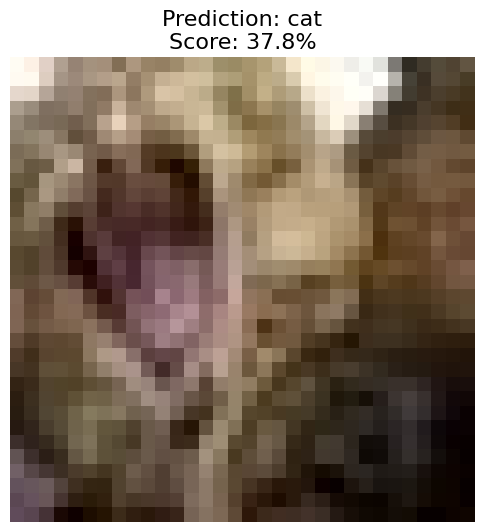

In [ ]:
img_path = "/content/test_images/img0.jpg"
inference(args, model, img_path)

# Post-Training Quantization

## Load Quantization Function

In [ ]:
def quantize_minmax(x: torch.Tensor, b=8):
    """Quantize Features & Weights Tensor using symmetric min-max quantization."""
    q_min = -2**(b-1)
    q_max = 2**(b-1)-1
    x_max = torch.max(x)
    x_min = torch.min(x)
    scale = (max(abs(x_max), abs(x_min))*2 / (q_max-q_min))
    quant_x = torch.clamp(torch.round(x / scale), min=q_min, max=q_max)
    dequant_x = quant_x * scale
    return dequant_x, scale

def quantize_bias_minmax(bias: torch.Tensor, scale_x, scale_w):
    """Quantize Bias Tensor using symmetric min-max quantization."""
    scale = scale_x * scale_w
    quant_bias = torch.round(bias / scale)
    dequant_bias = quant_bias * scale
    return dequant_bias

## Load Quantized CNN Model

In [ ]:
import torch.nn.functional as F

class Quantized_CNNModel(nn.Module):
    def __init__(self, num_class=10, act_funct=nn.ReLU):
        super().__init__()
        self.Conv0 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.Conv1 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.Linear0 = nn.Linear(in_features=8 * 8 * 16, out_features=1024)
        self.Linear1 = nn.Linear(in_features=1024, out_features=num_class)
        self.MaxPool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Act     = act_funct()

    def forward(self, input):
        # Layer0
        # Quantized
        InFmap_Conv0, scale_Conv0_x = quantize_minmax(input)
        weight_Conv0, scale_Conv0_w = quantize_minmax(self.Conv0.weight)
        bias_Conv0 = quantize_bias_minmax(self.Conv0.bias, scale_Conv0_x, scale_Conv0_w)

        output_layer0 = self.MaxPool(self.Act(F.conv2d(InFmap_Conv0, weight_Conv0, bias_Conv0, stride=self.Conv0.stride, padding=self.Conv0.padding)))

        # Layer1
        # Quantized
        output_layer0_Conv1, scale_Conv1_x = quantize_minmax(output_layer0)
        weight_Conv1, scale_Conv1_w = quantize_minmax(self.Conv1.weight)
        bias_Conv1 = quantize_bias_minmax(self.Conv1.bias, scale_Conv1_x, scale_Conv1_w)

        output_layer1 = self.MaxPool(self.Act(F.conv2d(output_layer0_Conv1, weight_Conv1, bias_Conv1, stride=self.Conv1.stride, padding=self.Conv1.padding)))

        # Layer2
        output_flatten = torch.flatten(output_layer1, start_dim=1)

        # Quantized
        output_flatten_linear0, scale_linear0_x = quantize_minmax(output_flatten)
        weight_linear0, scale_linear0_w = quantize_minmax(self.Linear0.weight)
        bias_linear0 = quantize_bias_minmax(self.Linear0.bias, scale_linear0_x, scale_linear0_w)

        output_layer2 = F.linear(output_flatten_linear0, weight_linear0, bias_linear0)

        # Layer3
        # Quantized
        output_flatten_linear1, scale_linear1_x = quantize_minmax(output_layer2)
        weight_linear1, scale_linear1_w = quantize_minmax(self.Linear1.weight)
        bias_linear1 = quantize_bias_minmax(self.Linear1.bias, scale_linear1_x, scale_linear1_w)

        output_layer3 = F.linear(output_flatten_linear1, weight_linear1, bias_linear1)
        return output_layer3

## Quantized Inference

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
quantized_model = Quantized_CNNModel(num_class=args.num_class).to(device)

==> Loading from checkpoint..
class_id:  3
cat: 36.4%


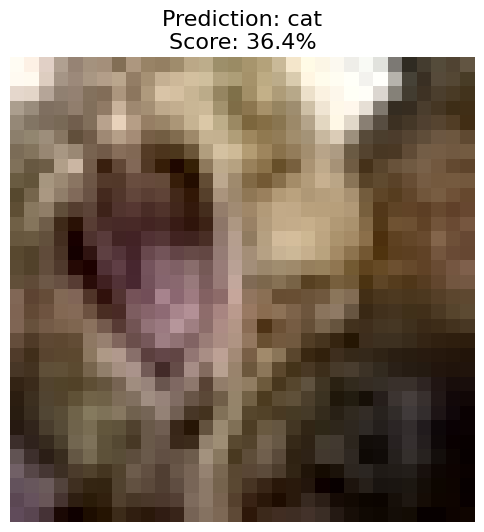

In [ ]:
img_path = "/content/test_images/img0.jpg"
inference(args, quantized_model, img_path)

## Quantized Validation

In [ ]:
validation(args, quantized_model)

Validating best model...
Best Top-1 Accuracy: 68.98%
Best Top-5 Accuracy: 97.21%
